Continued:
/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023.ipynb

## Merge mcool files of bioreps 1,2 and 3,4 at 0h, separately

In [1]:
bioreps=['HIC_K562_0000min_biorep1__hg38',
         'HIC_K562_0000min_biorep2__hg38',
         'HIC_K562_0000min_biorep3__hg38',
         'HIC_K562_0000min_biorep4__hg38',]

In [2]:
clr_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/'
# 0000min_R12
min0000_cool_R12=[]
for i in bioreps[:2]:
    min0000_cool_R12.append(f'{clr_dir}{i}/results/coolers_library/{i}.hg38.mapq_30.1000.mcool::resolutions/1000')
min0000_cool_R12=' '.join(min0000_cool_R12)

# 0000min_R34
min0000_cool_R34=[]
for i in bioreps[2:]:
    min0000_cool_R34.append(f'{clr_dir}{i}/results/coolers_library/{i}.hg38.mapq_30.1000.mcool::resolutions/1000')
min0000_cool_R34=' '.join(min0000_cool_R34)

In [3]:
min0000_merged_R12_1000=f'{clr_dir}HIC_K562_0000min_biorep1_to_2__hg38.hg38.mapq_30.1000.cool'
min0000_merged_R34_1000=f'{clr_dir}HIC_K562_0000min_biorep3_to_4__hg38.hg38.mapq_30.1000.cool'


In [4]:
# # min0000_merged_R12
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate hictk && hictk merge -o $min0000_merged_R12_1000 --threads 8 $min0000_cool_R12"


WARN: No span specified with (-n 8). Defaulting to span[hosts=1] (single host). See https://tinyurl.com/3rctk5j9
INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <838400> is submitted to queue <long>.


In [5]:
# # min0000_merged_R34
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate hictk && hictk merge -o $min0000_merged_R34_1000 --threads 8 $min0000_cool_R34"


WARN: No span specified with (-n 8). Defaulting to span[hosts=1] (single host). See https://tinyurl.com/3rctk5j9
INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <838404> is submitted to queue <long>.


In [6]:
min0000_merged_R12_mcool=f'{clr_dir}HIC_K562_0000min_biorep1_to_2__hg38.hg38.mapq_30.1000.mcool'
min0000_merged_R34_mcool=f'{clr_dir}HIC_K562_0000min_biorep3_to_4__hg38.hg38.mapq_30.1000.mcool'


In [7]:
# # 0000min_merged_R12 balanced
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=16G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate genomeinfodb-manual-versions2 && cooler zoomify --nproc 4 --resolutions 1000,2000,5000,10000 --balance --out $min0000_merged_R12_mcool $min0000_merged_R12_1000"


WARN: No span specified with (-n 4). Defaulting to span[hosts=1] (single host). See https://tinyurl.com/3rctk5j9
INFO: Total memory requested is 65536 MB (4 cores x 16384 MB)
Job <838441> is submitted to queue <long>.


In [8]:
# # 0000min_merged_R34 balanced
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=16G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate genomeinfodb-manual-versions2 && cooler zoomify --nproc 4 --resolutions 1000,2000,5000,10000 --balance --out $min0000_merged_R34_mcool $min0000_merged_R34_1000"


WARN: No span specified with (-n 4). Defaulting to span[hosts=1] (single host). See https://tinyurl.com/3rctk5j9
INFO: Total memory requested is 65536 MB (4 cores x 16384 MB)
Job <838442> is submitted to queue <long>.


In [9]:
import pandas as pd

In [12]:
# generate input file for cool path
clr_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/'

coolers = {'name': ['K562_0000min_R12',
                    'K562_0000min_R34'
                   ],
           'path': [clr_dir+'HIC_K562_0000min_biorep1_to_2__hg38.hg38.mapq_30.1000.mcool',
                    clr_dir+'HIC_K562_0000min_biorep3_to_4__hg38.hg38.mapq_30.1000.mcool'
                   ]} 
coolers = pd.DataFrame.from_dict(coolers)

# coolers.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_R12_and_R34_at_0h_Bond_et_al_2023.tsv', sep='\t', index=False, header=True)


In [11]:
coolers

,name,path
0,K562_0000min_R12,/home/jiangyuan.liu5-umw/projects/4DNII/public...
1,K562_0000min_R34,/home/jiangyuan.liu5-umw/projects/4DNII/public...


## Check number of reads and cis and trans ratios after ignore_diags=2 (default IC balancing) at 5 and 10kb resolutions

In [1]:
input_cooler_paths='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_R12_and_R34_at_0h_Bond_et_al_2023.tsv'
resolutions='5000,10000'
ignore_diags=2
output='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/cis_trans_count_summary_of_R12_and_R34_at_0h_5_and_10kb.tsv'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 1 -R "rusage[mem=256G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/calculate_cis_trans_counts_after_ignoring_specific_diagonals.py $input_cooler_paths $resolutions $ignore_diags $output"


Job <840995> is submitted to queue <long>.


In [1]:
import pandas as pd

output='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/cis_trans_count_summary_of_R12_and_R34_at_0h_5_and_10kb.tsv'
count_summary=pd.read_csv(output, sep='\t')[['condition','total','total_trans','total_trans_percent','total_cis','total_cis_percent','total_cis_without_2_diags','total_cis_without_2_diags_percent','resolution']]
count_summary['total'] = count_summary['total'].apply(lambda x: f'{x:,}')
count_summary['total_trans'] = count_summary['total_trans'].apply(lambda x: f'{x:,}')
count_summary['total_cis'] = count_summary['total_cis'].apply(lambda x: f'{x:,}')
count_summary['total_cis_without_2_diags'] = count_summary['total_cis_without_2_diags'].apply(lambda x: f'{x:,}')
count_summary.loc[count_summary.resolution == 5000, ['condition','total','total_trans','total_trans_percent','total_cis','total_cis_percent']].reset_index(drop=True)


,condition,total,total_trans,total_trans_percent,total_cis,total_cis_percent
0,K562_0000min_R12,"1,598,873,714","218,005,063",0.136349,"1,380,868,651",0.863651
1,K562_0000min_R34,"1,300,041,285","177,592,048",0.136605,"1,122,449,237",0.863395


## Old method

### Call loops at 5kb resolution for each individual library

In [14]:
input_coolers='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_R12_and_R34_at_0h_Bond_et_al_2023.tsv'
output_folder='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old_R12_vs_R34_at_0h'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Generate_dots_from_each_individual_libraries.py $input_coolers $output_folder"


WARN: No span specified with (-n 8). Defaulting to span[hosts=1] (single host). See https://tinyurl.com/3rctk5j9
INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <840293> is submitted to queue <long>.


### Merge loops called from each individual library

In [27]:
import pandas as pd
from matplotlib import pyplot as plt

In [28]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old_R12_vs_R34_at_0h/'
dots_meta=pd.read_csv(dots_dir+'dots_meta_5kb.tsv', sep='\t')

In [29]:
dots_list=[]
for i in range(len(dots_meta)):
    df=pd.read_csv(dots_meta.path[i], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    df['sample_name']=dots_meta.name[i]
    dots_list.append(df)
dots=pd.concat(dots_list)

In [30]:
import bioframe
import pandas as pd
import numpy as np

def merge_dots(df):
    overlapped_anchors_left=bioframe.cluster(df[['chrom1','start1','end1']].copy().rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end'}), min_dist=None)
    overlapped_anchors_right=bioframe.cluster(df[['chrom2','start2','end2','sample_name']].copy().rename(columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end'}), min_dist=None)
    overlapped_dots=pd.merge(overlapped_anchors_left, overlapped_anchors_right, left_index=True, right_index=True, suffixes=(1,2))
    sample_name=overlapped_dots.groupby(['cluster1','cluster2'])['sample_name'].apply(lambda x: '&'.join(list(np.unique(x)))).reset_index()
    overlapped_dots=pd.merge(overlapped_dots[['cluster1','cluster2','chrom1','cluster_start1','cluster_end1','chrom2','cluster_start2','cluster_end2']], sample_name, on=['cluster1','cluster2'])
    overlapped_dots=overlapped_dots.drop(['cluster1', 'cluster2'], axis=1).rename(columns={'cluster_start1': 'start1', 'cluster_end1': 'end1', 'cluster_start2': 'start2', 'cluster_end2': 'end2'})
    overlapped_dots=overlapped_dots.drop_duplicates().reset_index(drop=True)
    return overlapped_dots



In [31]:
merged_dots=merge_dots(dots)

In [32]:
len(merged_dots) # Total 12492 loops

4842

In [33]:
merged_dots.head()

,chrom1,start1,end1,chrom2,start2,end2,sample_name
0,chr10,6910000,6915000,chr10,7415000,7420000,K562_0000min_R12
1,chr10,17280000,17285000,chr10,17585000,17590000,K562_0000min_R12
2,chr10,15430000,15435000,chr10,15720000,15725000,K562_0000min_R12&K562_0000min_R34
3,chr10,11785000,11790000,chr10,11980000,11985000,K562_0000min_R12
4,chr10,6425000,6430000,chr10,6660000,6665000,K562_0000min_R12


In [34]:
# merged_dots.to_csv(dots_dir+'union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.txt', sep='\t', index=False, header=True)


## New method: Generate a union list of loops using my nextflow pipeline at 5kb resolution for R12 and R34 at 0h

In [ ]:
# Run my pipeline
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new_R12_vs_R34_at_0h
# bsub < run.sh


### Upset plot (R kernel) (old method)

In [1]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

Warning message:
“package ‘UpSetR’ was built under R version 4.0.5”
Warning message:
“package ‘stringr’ was built under R version 4.0.5”


In [2]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old_R12_vs_R34_at_0h/union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.txt', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

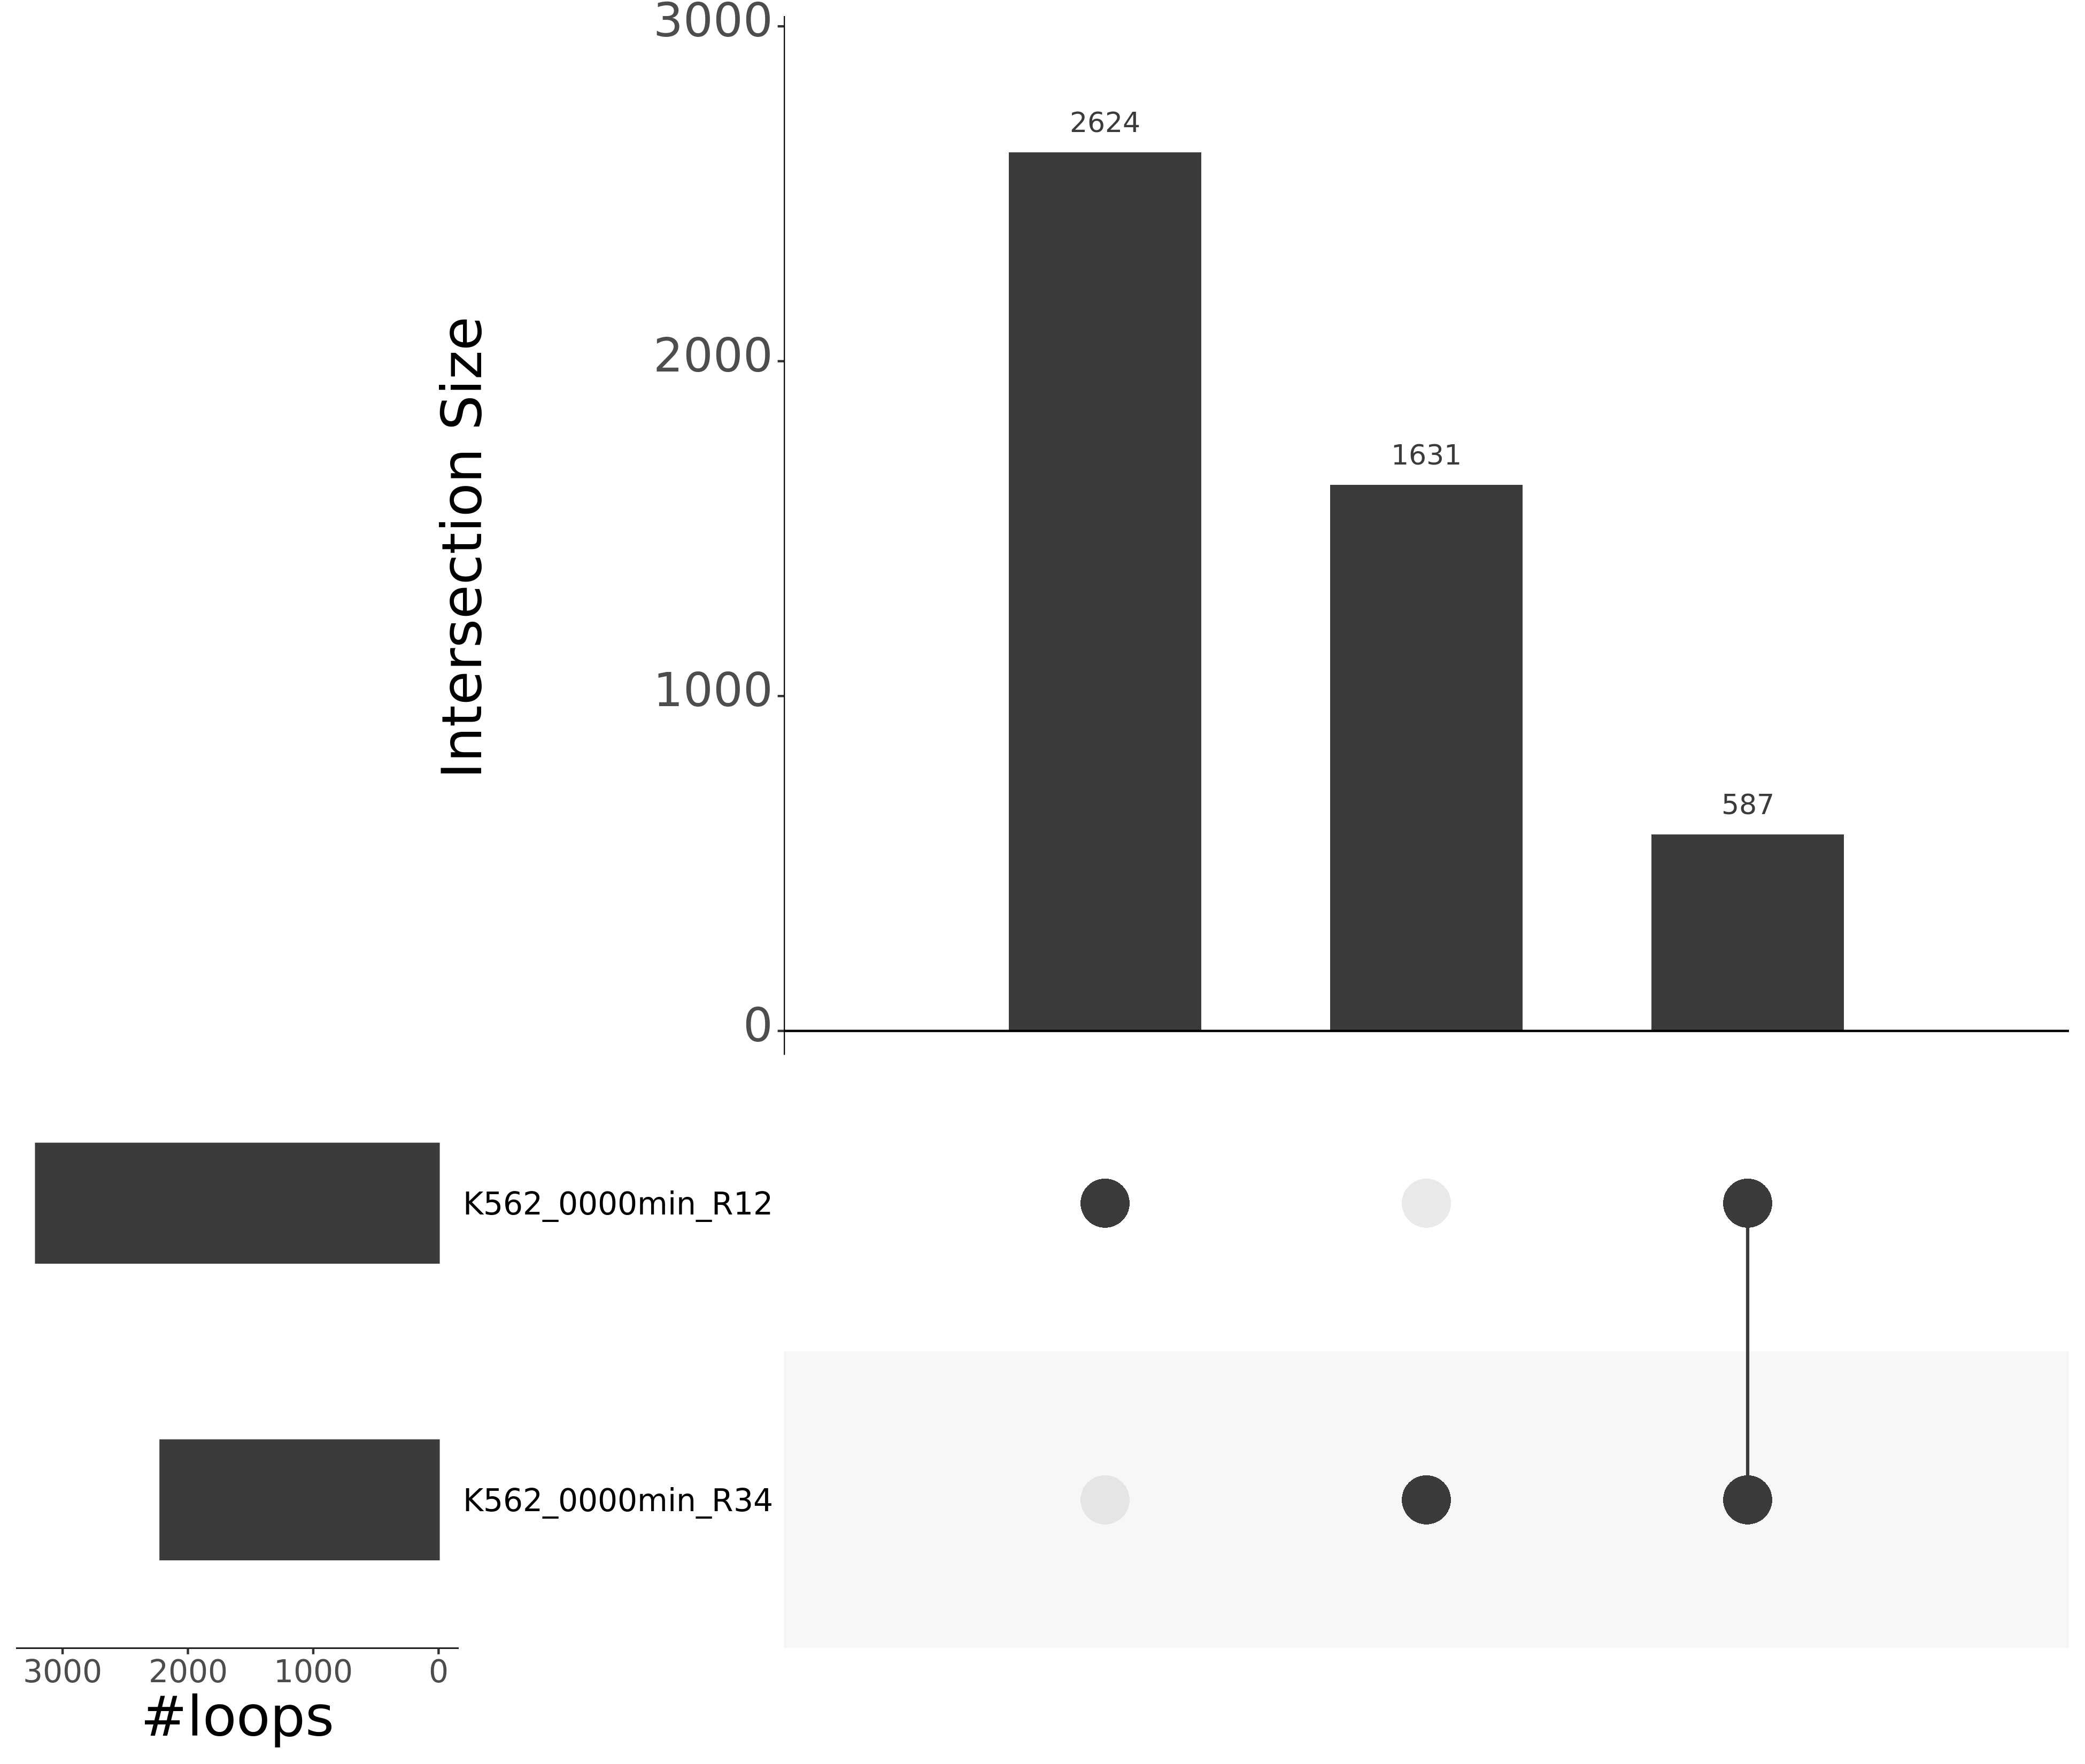

In [3]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 7,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=10,
      mb.ratio = c(0.6, 0.4),
      sets = c('K562_0000min_R34',
               'K562_0000min_R12'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


### R kernel (local laptop)

In [ ]:
#  Bond et al 2023 (5kb, old method)

library(ComplexHeatmap)

df1 <- read.table(file = 'union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.txt', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- setNames(list(
  K562_0000min_R1R2 = which(grepl("K562_0000min_R12", df1$sample_name)),
  K562_0000min_R3R4 = which(grepl("K562_0000min_R34", df1$sample_name))
), c("0 hour (R1R2)", "0 hour (R3R4)")
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("0 hour (R1R2)", "0 hour (R3R4)")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 3
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S10
pdf("upset_plot_of_union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()



In [ ]:
> sessionInfo()
R version 4.1.1 (2021-08-10)
Platform: x86_64-apple-darwin17.0 (64-bit)
Running under: macOS Monterey 12.7.6

Matrix products: default
LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ComplexHeatmap_2.10.0

loaded via a namespace (and not attached):
 [1] pillar_1.9.0        compiler_4.1.1      RColorBrewer_1.1-3  iterators_1.0.14    tools_4.1.1         digest_0.6.37      
 [7] lifecycle_1.0.4     tibble_3.2.1        clue_0.3-66         pkgconfig_2.0.3     png_0.1-8           rlang_1.1.6        
[13] foreach_1.5.2       cli_3.6.5           rstudioapi_0.17.1   parallel_4.1.1      cluster_2.1.8.1     dplyr_1.1.4        
[19] generics_0.1.4      vctrs_0.6.5         GlobalOptions_0.1.2 S4Vectors_0.32.4    IRanges_2.28.0      stats4_4.1.1       
[25] tidyselect_1.2.1    glue_1.8.0          R6_2.6.1            GetoptLong_1.0.5    fansi_1.0.6         magrittr_2.0.4     
[31] codetools_0.2-20    matrixStats_1.5.0   BiocGenerics_0.40.0 shape_1.4.6.1       circlize_0.4.16     colorspace_2.1-2   
[37] utf8_1.2.4          doParallel_1.0.17   crayon_1.5.3        rjson_0.2.23     

### Pileup plot corresponding to above upset plots (old method)

In [1]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['K562_0000min_R12','K562_0000min_R34'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [2]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old_R12_vs_R34_at_0h/'
dots=pd.read_csv(dots_dir+'union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.txt', sep='\t')


In [3]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=3
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [58]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old_R12_vs_R34_at_0h/'
dots_file=dots_dir+'union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.txt'
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_R12_and_R34_at_0h_Bond_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='K562_0000min_R12,K562_0000min_R34'

resolution=5000
flank=50000
output=dots_dir+'pileup_matrices_of_subsets_of_union_dot_list_5kb_resolution_50kb_flank.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"


In [59]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.55,
                vmin = -0.55,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.55, 0, 0.55])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


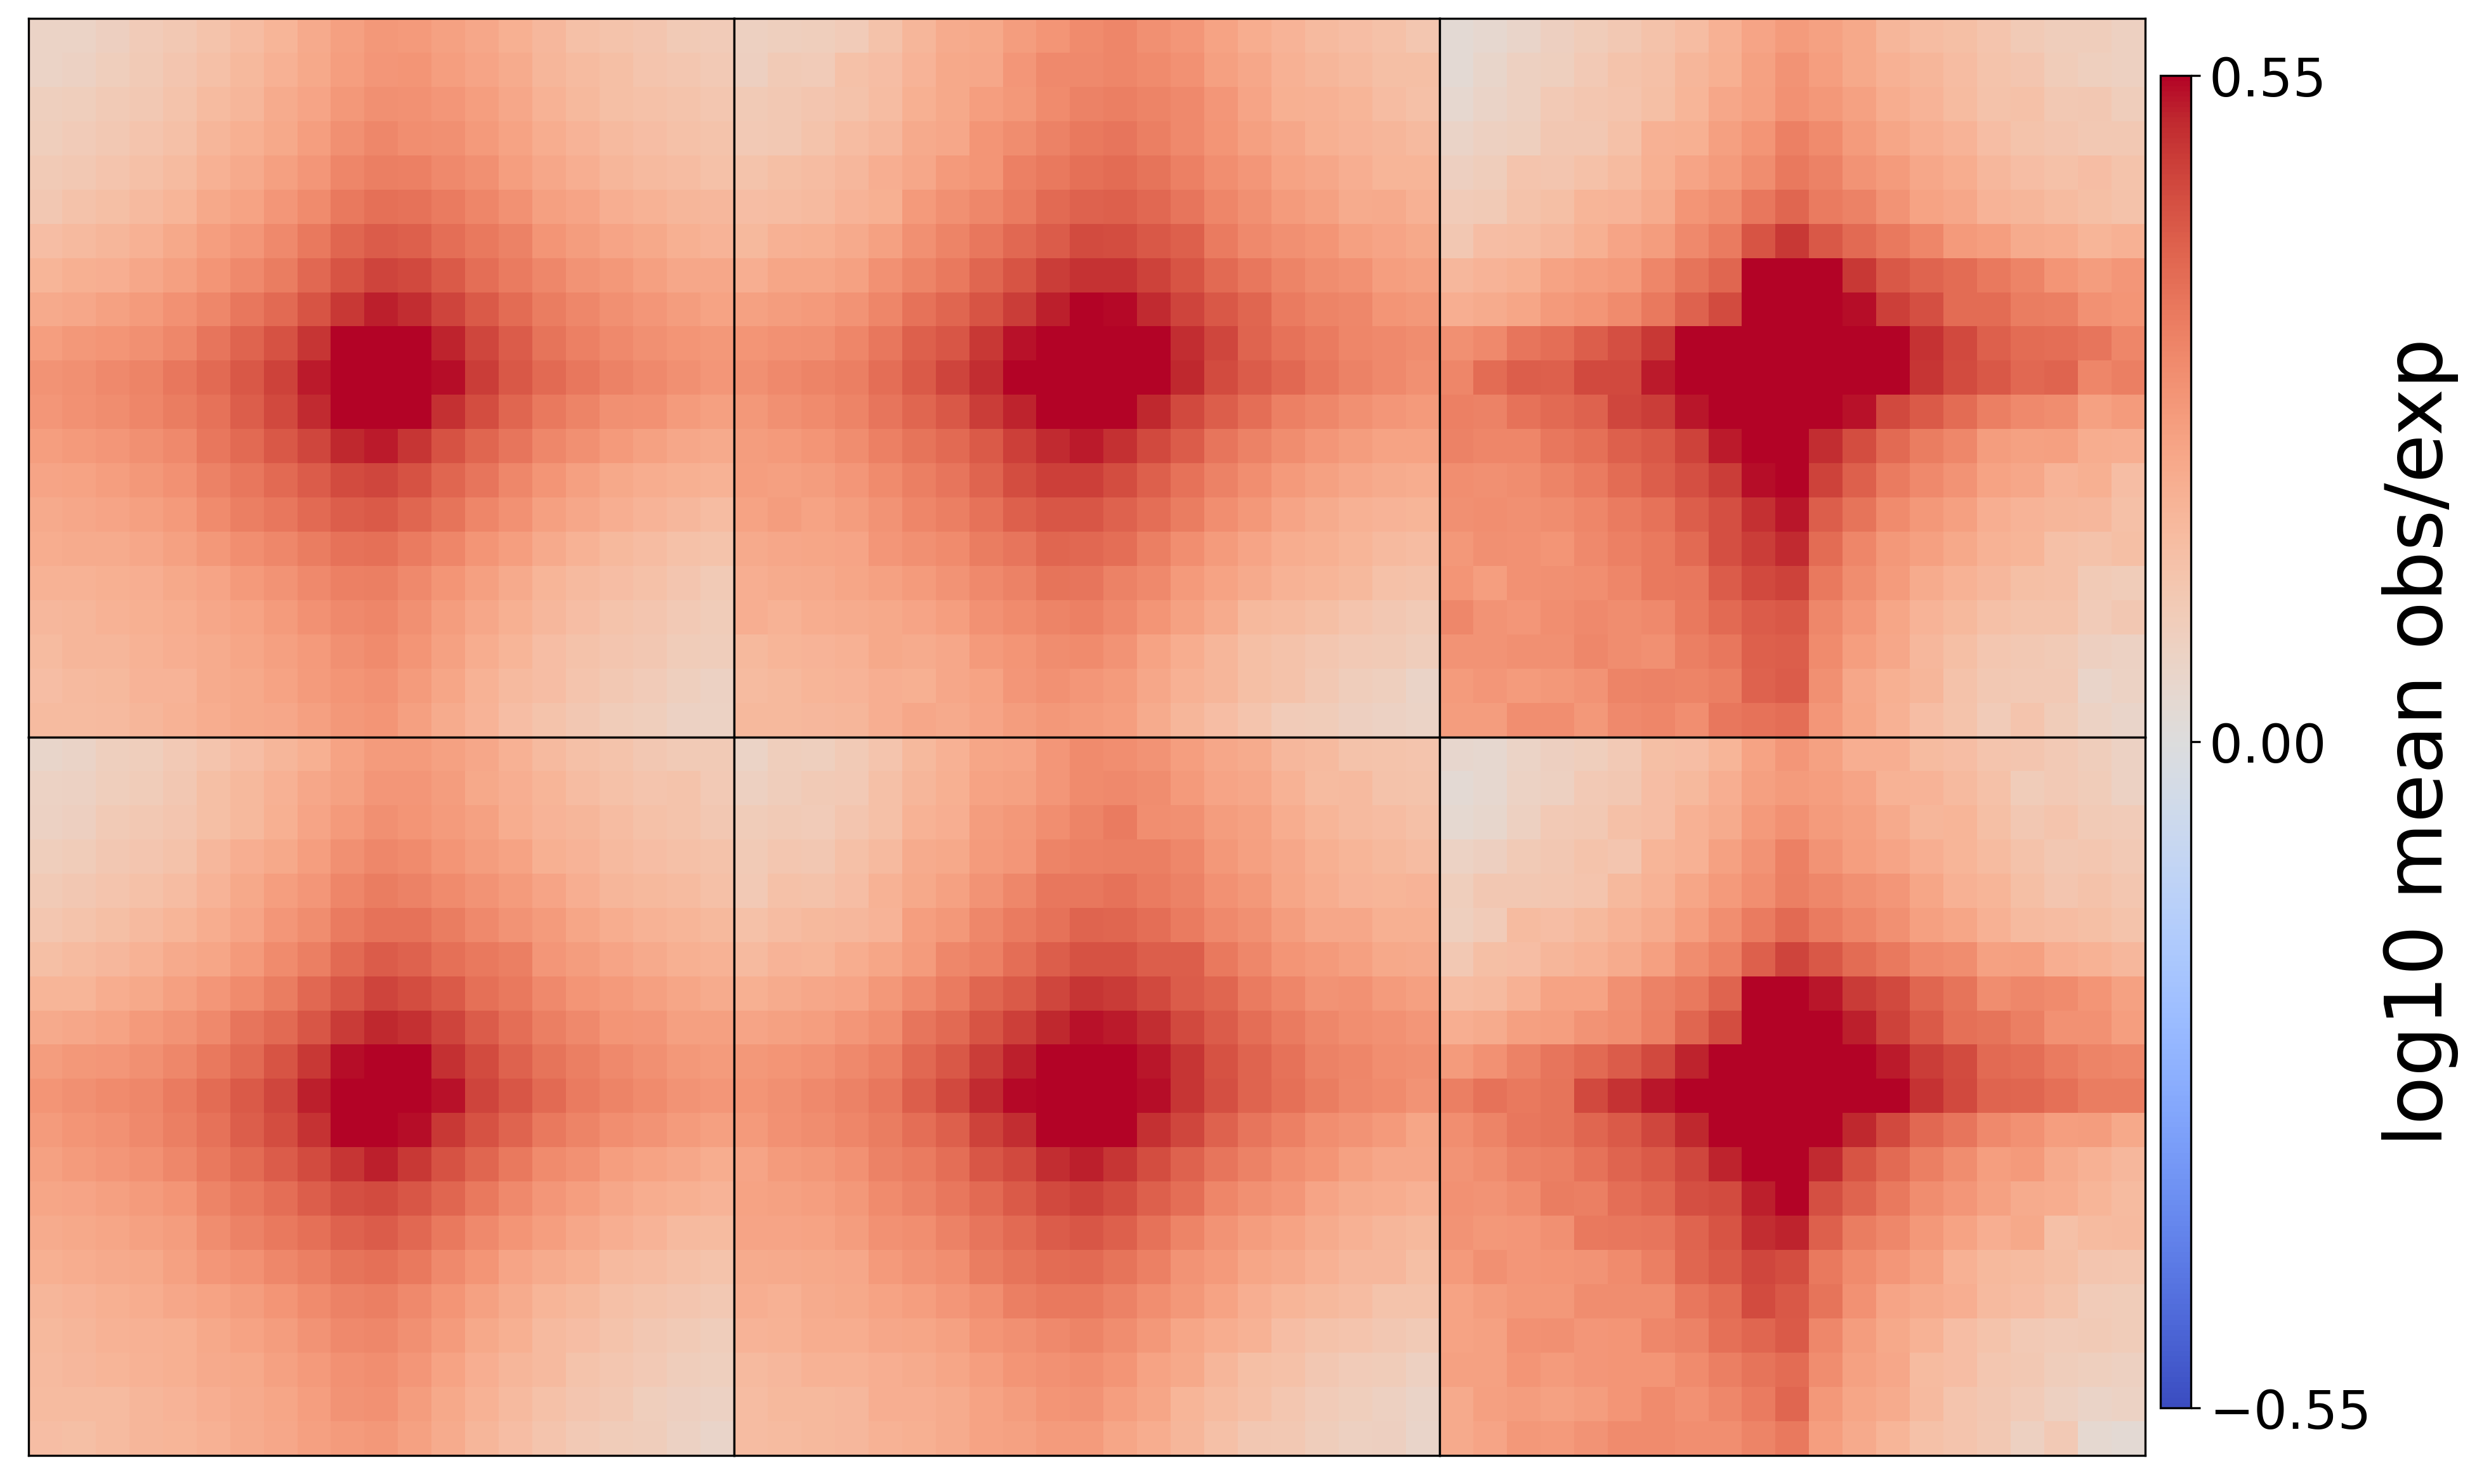

In [60]:
libraries_names=['K562_0000min_R12','K562_0000min_R34']

generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=5000,
                                    flank=50000,
                                    width=16,
                                    height=10,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S10/pileup_plot_of_union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_old_method.svg')



### Upset plot (R kernel) (new method)

In [4]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

In [5]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new_R12_vs_R34_at_0h/results/Bond_et_al_2023_R12_and_R34_at_0h_union_loop_list_5kb.tsv', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

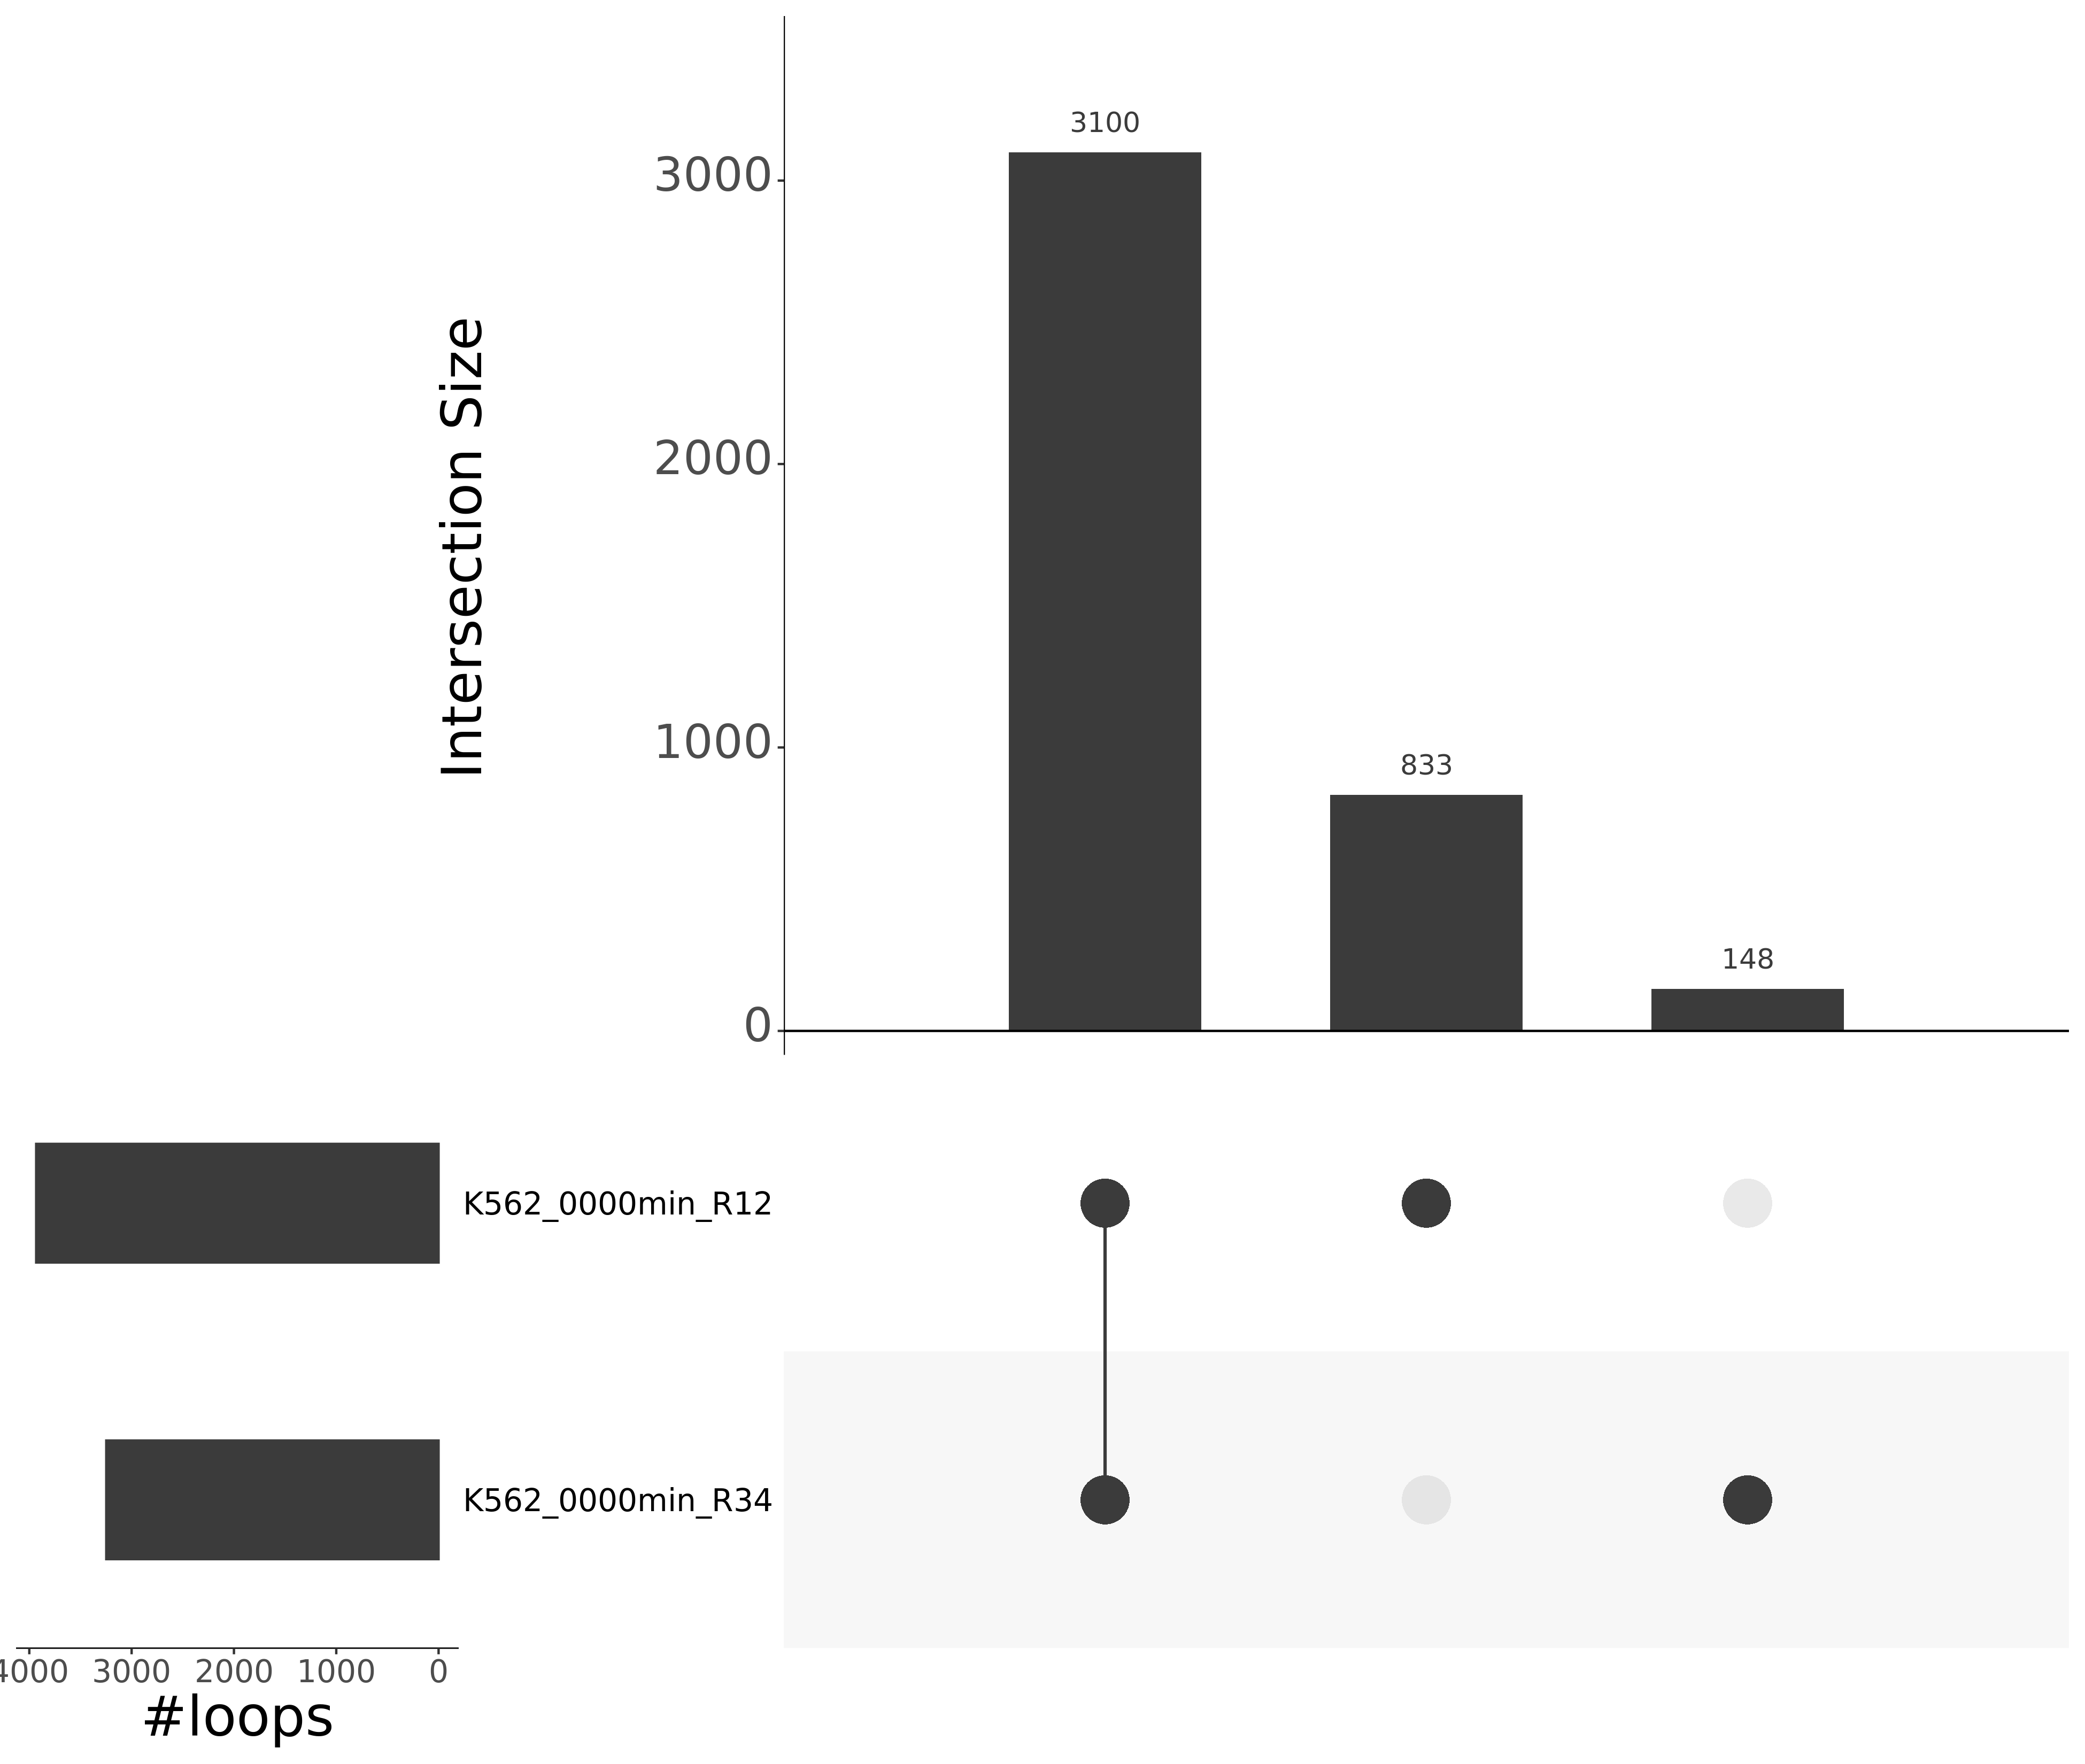

In [6]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 7,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=10,
      mb.ratio = c(0.6, 0.4),
      sets = c('K562_0000min_R34',
               'K562_0000min_R12'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


In [ ]:
#  Bond et al 2023 (5kb, new method)

library(ComplexHeatmap)

df1 <- read.table(file = 'Bond_et_al_2023_R12_and_R34_at_0h_union_loop_list_5kb.tsv', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- setNames(list(
  K562_0000min_R1R2 = which(grepl("K562_0000min_R12", df1$sample_name)),
  K562_0000min_R3R4 = which(grepl("K562_0000min_R34", df1$sample_name))
), c("0 hour (R1R2)", "0 hour (R3R4)")
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("0 hour (R1R2)", "0 hour (R3R4)")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 3
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S10
pdf("upset_plot_of_union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_new_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()



In [ ]:
> sessionInfo()
R version 4.1.1 (2021-08-10)
Platform: x86_64-apple-darwin17.0 (64-bit)
Running under: macOS Monterey 12.7.6

Matrix products: default
LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ComplexHeatmap_2.10.0

loaded via a namespace (and not attached):
 [1] pillar_1.9.0        compiler_4.1.1      RColorBrewer_1.1-3  iterators_1.0.14    tools_4.1.1         digest_0.6.37      
 [7] lifecycle_1.0.4     tibble_3.2.1        clue_0.3-66         pkgconfig_2.0.3     png_0.1-8           rlang_1.1.6        
[13] foreach_1.5.2       cli_3.6.5           rstudioapi_0.17.1   parallel_4.1.1      cluster_2.1.8.1     dplyr_1.1.4        
[19] generics_0.1.4      vctrs_0.6.5         GlobalOptions_0.1.2 S4Vectors_0.32.4    IRanges_2.28.0      stats4_4.1.1       
[25] tidyselect_1.2.1    glue_1.8.0          R6_2.6.1            GetoptLong_1.0.5    fansi_1.0.6         magrittr_2.0.4     
[31] codetools_0.2-20    matrixStats_1.5.0   BiocGenerics_0.40.0 shape_1.4.6.1       circlize_0.4.16     colorspace_2.1-2   
[37] utf8_1.2.4          doParallel_1.0.17   crayon_1.5.3        rjson_0.2.23

### Pileup plot corresponding to above upset plots (new method)

In [1]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['K562_0000min_R12','K562_0000min_R34'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [2]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new_R12_vs_R34_at_0h/'
dots=pd.read_csv(dots_dir+'results/Bond_et_al_2023_R12_and_R34_at_0h_union_loop_list_5kb.tsv', sep='\t')


In [3]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=3
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [61]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new_R12_vs_R34_at_0h/'
dots_file=dots_dir+'results/Bond_et_al_2023_R12_and_R34_at_0h_union_loop_list_5kb.tsv'
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_R12_and_R34_at_0h_Bond_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='K562_0000min_R12,K562_0000min_R34'

resolution=5000
flank=50000
output=dots_dir+'pileup_matrices_of_subsets_of_union_dot_list_5kb_resolution_50kb_flank.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"


In [62]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.55,
                vmin = -0.55,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.55, 0, 0.55])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


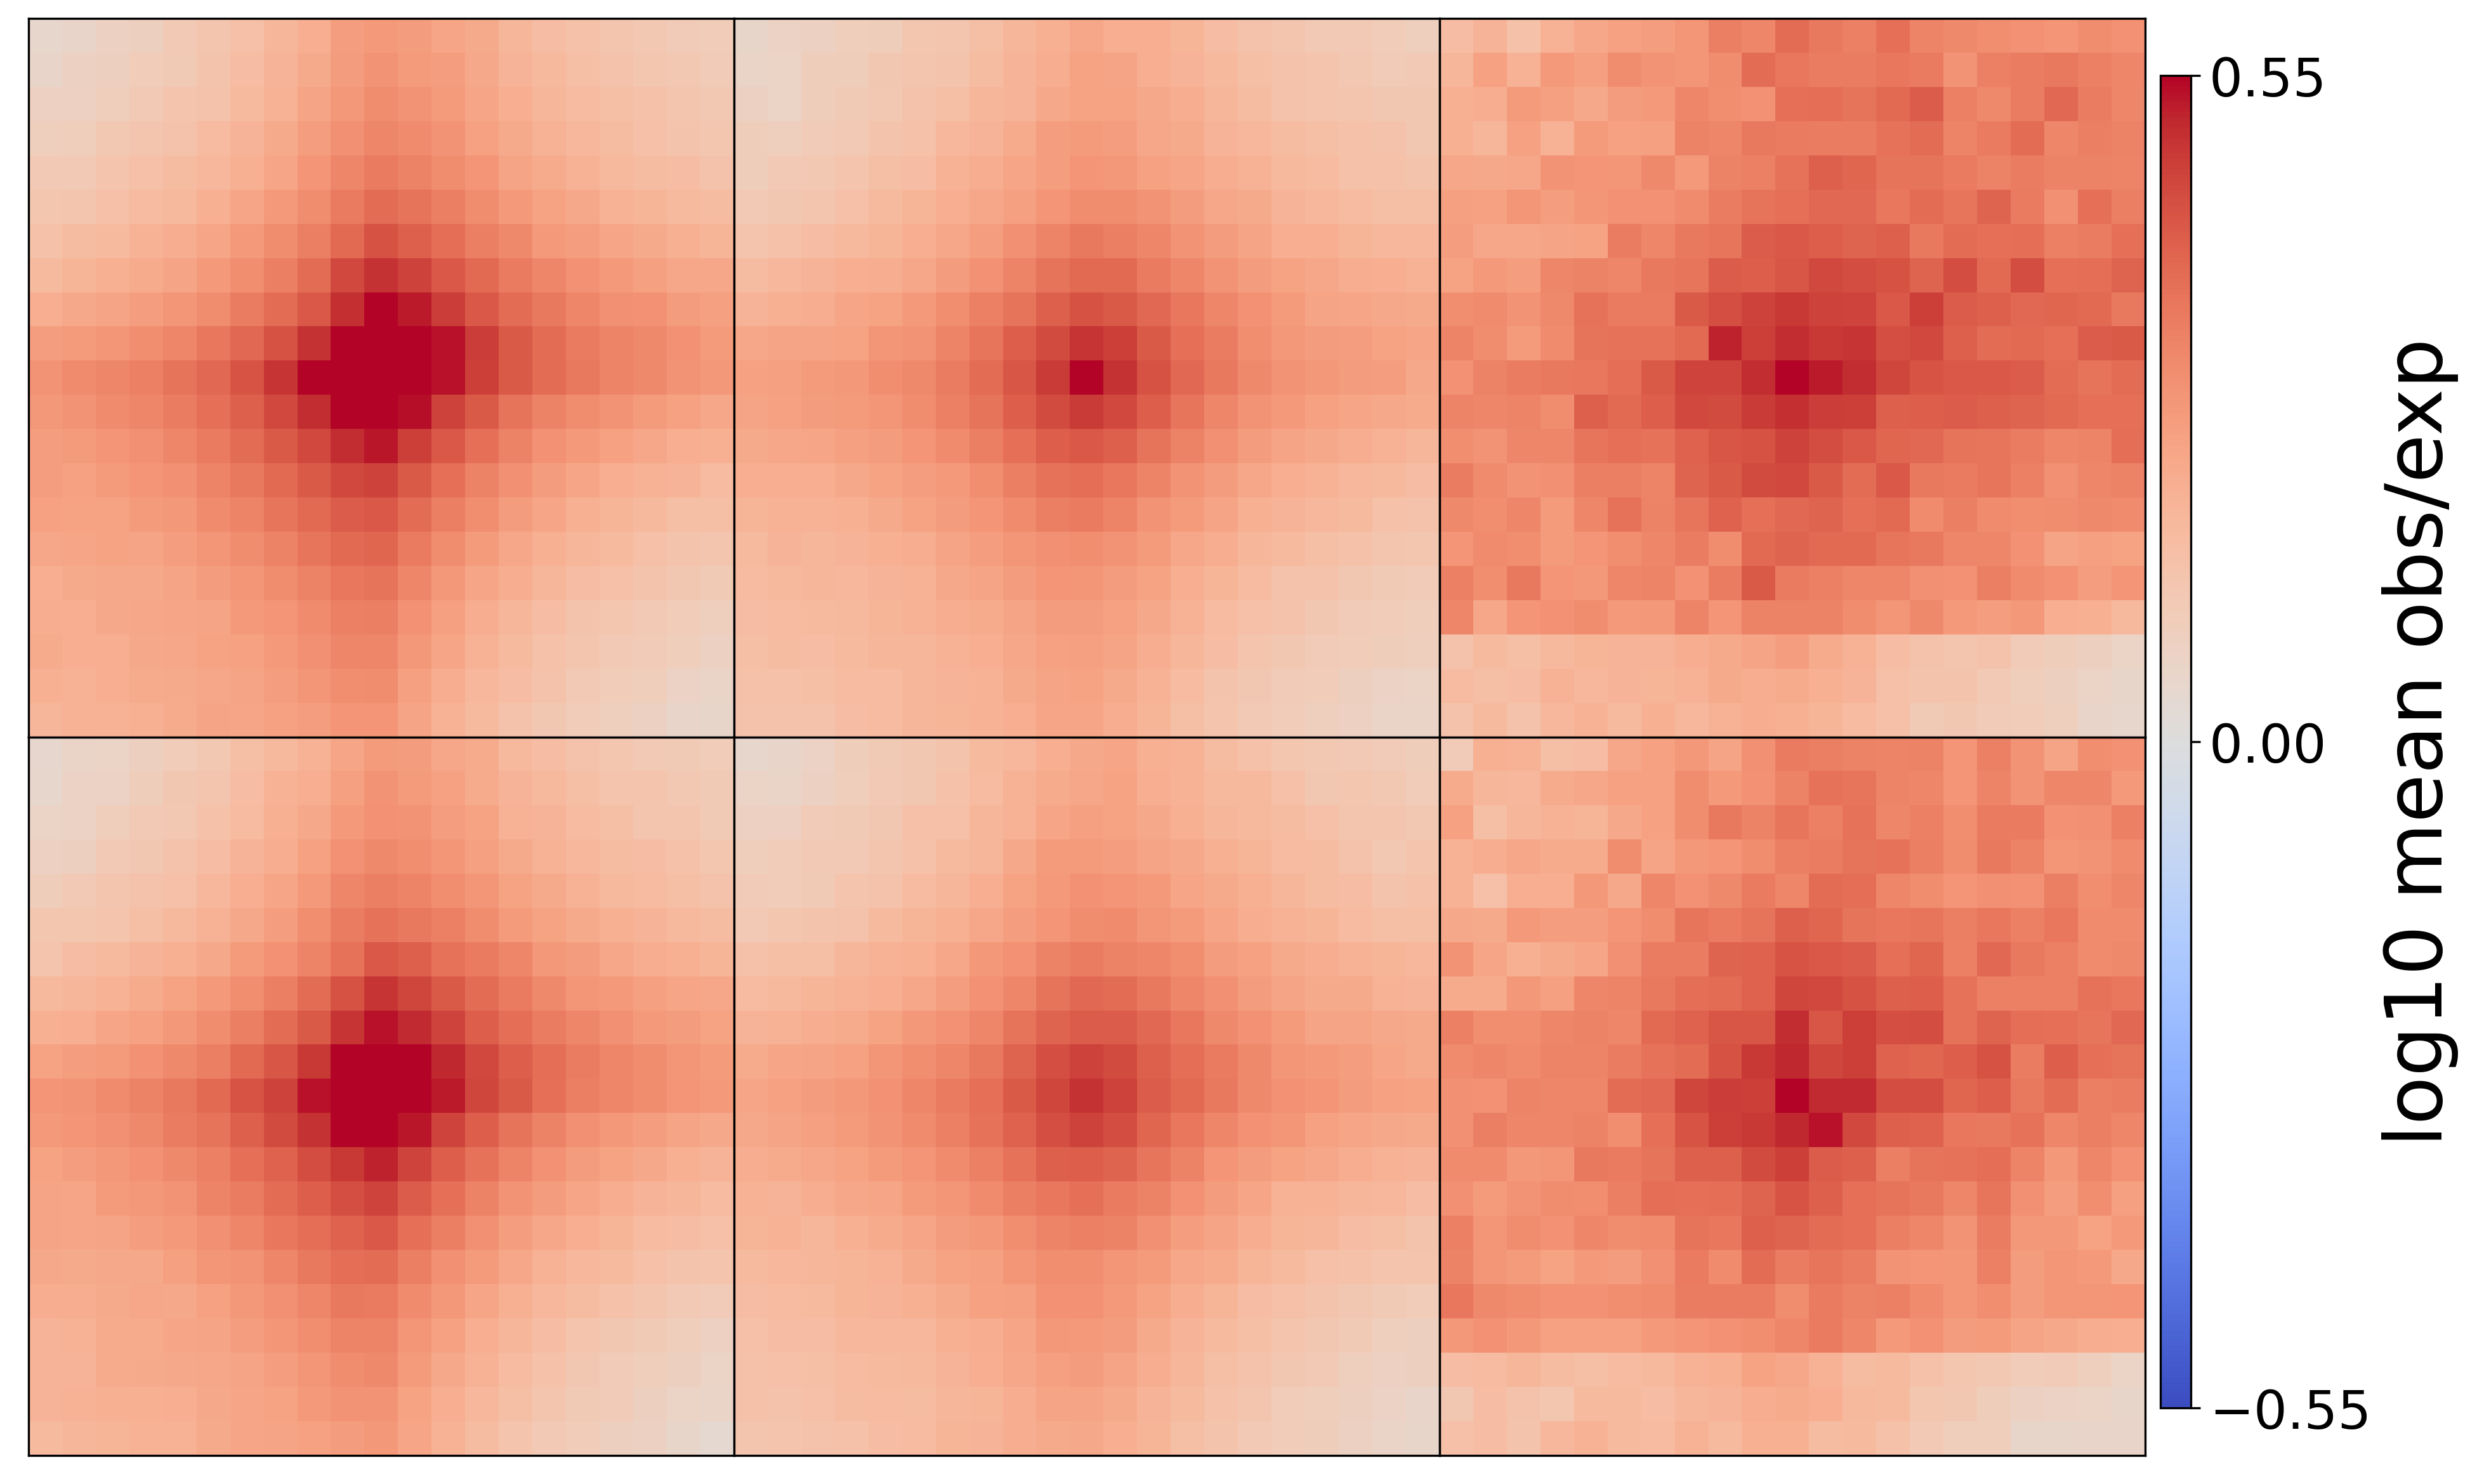

In [63]:
libraries_names=['K562_0000min_R12','K562_0000min_R34']

generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=5000,
                                    flank=50000,
                                    width=16,
                                    height=10,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S10/pileup_plot_of_union_dot_list_of_R12_and_R34_at_0h_Bond_et_al_2023_5kb_new_method.svg')

